# Contrastive Learning

In [76]:
import os
import glob
import json
import random
import pickle
import hashlib
from dataclasses import dataclass, asdict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SubsetRandomSampler

from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (
    classification_report, balanced_accuracy_score, accuracy_score,
    roc_curve, auc, confusion_matrix, pairwise_distances, silhouette_score,
)

import optuna
from optuna.pruners import MedianPruner

# Part 1 : Contrastive model

## Shared utilities + hyperparameter search

In [ ]:
DATA_ROOT = '/media/Data/Yona/WSI CCRCC'
CSV_PATH  = f'{DATA_ROOT}/medical_genomic_data/clinical+genomic_split.csv'
FEAT_DIR  = f'{DATA_ROOT}/WSI_features_MaxPooling'
STEP1_OUT           = f'{DATA_ROOT}/runs_supcon_step1_100'
STEP2_TRAINONLY_OUT = f'{DATA_ROOT}/runs_supcon_step2_trainonly'  
STEP2_OUT           = f'{DATA_ROOT}/runs_supcon_step2_final'       
CV_EMBED_OUT        = f'{DATA_ROOT}/runs_supcon_cv_embeddings'     
NESTED_CV_OUT        = f'{DATA_ROOT}/runs_supcon_nested_cv'       
STEP3_OUT           = f'{DATA_ROOT}/runs_supcon_step3_eval'      

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ── Supervised contrastive loss (multi-view) ──────────────────────────────────
class SupConLossMV(nn.Module):
    def __init__(self, temperature=0.07, exclude_same_patient=True):
        super().__init__()
        self.temperature = temperature
        self.exclude_same_patient = exclude_same_patient

    def forward(self, features, labels, pids=None):
        device = features.device
        B, V, D = features.shape
        feats = F.normalize(features, dim=2).view(B * V, D)
        labels = labels.view(-1, 1)
        mask_labels = torch.eq(labels, labels.T).float()
        if self.exclude_same_patient and pids is not None:
            pids_np = np.asarray(pids)
            same_pid = torch.tensor(pids_np[:, None] == pids_np[None, :], dtype=torch.float, device=device)
            mask_labels = mask_labels * (1.0 - same_pid)
        mask = mask_labels.repeat_interleave(V, dim=0).repeat_interleave(V, dim=1)
        logits = torch.matmul(feats, feats.T) / self.temperature
        logits_mask = 1.0 - torch.eye(B * V, device=device)
        mask = mask * logits_mask
        logits_max, _ = logits.max(dim=1, keepdim=True)
        logits = logits - logits_max.detach()
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)
        pos_count = mask.sum(1)
        return -(mask * log_prob).sum(1).div(pos_count + 1e-12).mean()


def augment_vectors(x, noise_std=0.06, drop_prob=0.25, scale_jitter=0.10):
    x_aug = x + torch.randn_like(x) * noise_std
    x_aug = x_aug * (torch.rand_like(x_aug) > drop_prob).float()
    if scale_jitter > 0:
        scale = 1.0 + (2.0 * torch.rand(x.size(0), 1, device=x.device) - 1.0) * scale_jitter
        x_aug = x_aug * scale
    return x_aug


# ── Contrastive projector + classifier ───────────────────────────────────────
class SupConMLP(nn.Module):
    def __init__(self, input_dim=2048, embed_dim=128, dropout_rate=0.5):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),  nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(512, embed_dim)
        )
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, x):
        z = self.projector(x)
        return z, self.classifier(z)


# ── Dataset ───────────────────────────────────────────────────────────────────
class WSIEmbeddingDataset(Dataset):
    """Loads .npz embeddings for one or more CSV split names, optionally restricted to an
    explicit patient_id allowlist (used to carve out nested-CV folds without touching the
    CSV 'Split' column)."""
    def __init__(self, csv_path, features_dir, splits=('train',), patient_ids=None):
        if isinstance(splits, str):
            splits = (splits,)
        wanted = {s.strip().lower() for s in splits}
        allowed_pids = set(patient_ids) if patient_ids is not None else None
        df = pd.read_csv(csv_path)[['case_id', 'vital_status_12', 'Split']]
        data_list = []
        for _, row in df.iterrows():
            if str(row['Split']).strip().lower() not in wanted:
                continue
            cid = str(row['case_id']).strip()
            lbl = int(row['vital_status_12'])
            if cid.startswith('C'):
                pid = cid
            elif cid.startswith('T'):
                parts = cid.split('-')
                if len(parts) < 3:
                    continue
                pid = '-'.join(parts[:3])
            else:
                continue
            if allowed_pids is not None and pid not in allowed_pids:
                continue
            for fp in glob.glob(os.path.join(features_dir, f'{pid}-*.npz')):
                data_list.append({'patient_id': pid, 'label': lbl, 'file_path': fp})
        self.data_list = data_list

    def __len__(self): return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        arr = np.load(item['file_path'])
        feat = arr['features'].reshape(-1, arr['features'].shape[-1])[0]  # do not touch
        return torch.tensor(feat, dtype=torch.float), item['label'], item['patient_id']


def make_balanced_loader(ds, batch_size=128, num_workers=4, seed=42):
    labels = [ds[i][1] for i in range(len(ds))]
    cnt = Counter(labels)
    total = len(labels)
    w = {l: total / (len(cnt) * c) for l, c in cnt.items()}
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, num_workers=num_workers, generator=g,
                      sampler=WeightedRandomSampler([w[l] for l in labels], num_samples=total, replacement=True))


def make_plain_loader(ds, batch_size=256, num_workers=4, shuffle=False):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


# ── HParams + training helpers ───────────────
@dataclass
class HParams:
    epochs: int = 60
    batch_size: int = 128
    lr: float = 5e-4
    temperature: float = 0.07
    noise_std: float = 0.06
    drop_prob: float = 0.25
    scale_jitter: float = 0.10
    lambda_ce: float = 0.1
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    dropout_rate: float = 0.5
    exclude_same_patient: bool = True
    patience: int = 10
    seed: int = 42


def build_ce_loss_from_dataset(ds, device):
    lbls = [ds[i][1] for i in range(len(ds))]
    cnt = Counter(lbls)
    total = len(lbls)
    w = torch.tensor([total / cnt[i] for i in sorted(cnt)], dtype=torch.float, device=device)
    return nn.CrossEntropyLoss(weight=w)


@torch.no_grad()
def validate_epoch(model, loader, supcon, ce, hp: HParams, device):
    model.eval()
    run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
    for x_cpu, y_cpu, pid_batch in loader:
        x, y = x_cpu.to(device), y_cpu.to(device)
        x1 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
        x2 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
        z1, _ = model(x1); z2, _ = model(x2)
        feats  = torch.stack([F.normalize(z1, dim=1), F.normalize(z2, dim=1)], dim=1)
        loss_s = supcon(feats, y, pids=pid_batch)
        loss_c = ce(model.classifier((z1 + z2) / 2.0), y)
        loss   = loss_s + hp.lambda_ce * loss_c
        bs = x.size(0)
        run_s += loss_s.item() * bs; run_c += loss_c.item() * bs; run_t += loss.item() * bs; n += bs
    return {'val_supcon': run_s/max(n,1), 'val_ce': run_c/max(n,1), 'val_total': run_t/max(n,1)}


def make_run_id(hp: HParams) -> str:
    return hashlib.md5(json.dumps(asdict(hp), sort_keys=True).encode()).hexdigest()[:10]


def train_one_run(hp: HParams, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    torch.manual_seed(hp.seed); np.random.seed(hp.seed)
    train_ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train',))
    val_ds   = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('validation',))
    train_loader = make_balanced_loader(train_ds, batch_size=hp.batch_size, seed=hp.seed)
    val_loader   = make_plain_loader(val_ds, batch_size=256, shuffle=False)
    model  = SupConMLP(dropout_rate=hp.dropout_rate).to(device)
    supcon = SupConLossMV(temperature=hp.temperature, exclude_same_patient=hp.exclude_same_patient).to(device)
    ce     = build_ce_loss_from_dataset(train_ds, device)
    opt    = torch.optim.Adam(model.parameters(), lr=hp.lr, weight_decay=hp.weight_decay)
    best_val, best_path, history, bad = float('inf'), os.path.join(out_dir, 'best_model.pth'), [], 0
    for ep in range(1, hp.epochs + 1):
        model.train()
        run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
        for x_cpu, y_cpu, pid_batch in train_loader:
            x, y = x_cpu.to(device), y_cpu.to(device)
            x1 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
            x2 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
            z1, _ = model(x1); z2, _ = model(x2)
            feats  = torch.stack([F.normalize(z1,dim=1), F.normalize(z2,dim=1)], dim=1)
            loss_s = supcon(feats, y, pids=pid_batch)
            loss_c = ce(model.classifier((z1+z2)/2.0), y)
            loss   = loss_s + hp.lambda_ce * loss_c
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), hp.grad_clip)
            opt.step()
            bs = x.size(0)
            run_s+=loss_s.item()*bs; run_c+=loss_c.item()*bs; run_t+=loss.item()*bs; n+=bs
        train_m = {'epoch':ep, 'train_supcon':run_s/max(n,1), 'train_ce':run_c/max(n,1), 'train_total':run_t/max(n,1)}
        val_m   = validate_epoch(model, val_loader, supcon, ce, hp, device)
        row     = {**train_m, **val_m}
        history.append(row)
        print(f'[{os.path.basename(out_dir)}|E{ep:02d}] train {row["train_total"]:.4f} val {row["val_total"]:.4f}')
        if row['val_total'] < best_val - 1e-5:
            best_val, bad = row['val_total'], 0
            torch.save({'model_state': model.state_dict(), 'hparams': asdict(hp), 'best_val_total': best_val, 'epoch': ep}, best_path)
        else:
            bad += 1
            if bad >= hp.patience: break
    with open(os.path.join(out_dir, 'history.json'), 'w') as f: json.dump(history, f, indent=2)
    with open(os.path.join(out_dir, 'hparams.json'), 'w') as f: json.dump(asdict(hp), f, indent=2)
    return best_val, best_path


def sample_hparams(rng: np.random.Generator, base: HParams) -> HParams:
    hp = HParams(**asdict(base))
    hp.epochs       = int(rng.integers(30, 81))
    hp.patience     = int(rng.integers(6, 13))
    hp.batch_size   = int(rng.choice([64, 128, 256]))
    hp.lr           = float(10 ** rng.uniform(np.log10(1e-4), np.log10(1e-3)))
    hp.temperature  = float(rng.choice([0.03, 0.05, 0.07, 0.10, 0.15]))
    hp.noise_std    = float(rng.uniform(0.02, 0.10))
    hp.drop_prob    = float(rng.uniform(0.05, 0.40))
    hp.scale_jitter = float(rng.uniform(0.00, 0.20))
    hp.lambda_ce    = float(rng.choice([0.0, 0.05, 0.1, 0.2, 0.3]))
    hp.dropout_rate = float(rng.choice([0.1, 0.3, 0.5]))
    hp.weight_decay = float(10 ** rng.uniform(np.log10(1e-6), np.log10(5e-4)))
    hp.grad_clip    = float(rng.choice([0.5, 1.0, 2.0, 5.0]))
    hp.exclude_same_patient = True
    hp.seed = 42
    return hp


def run_100_trials(n_trials=100, master_seed=123):
    os.makedirs(STEP1_OUT, exist_ok=True)
    base_hp = HParams()
    rng     = np.random.default_rng(master_seed)
    best    = {'val': float('inf'), 'path': None, 'hparams': None, 'trial': None}
    results = []
    seen    = set()
    for t in range(1, n_trials + 1):
        hp = sample_hparams(rng, base_hp)
        run_id = make_run_id(hp)
        tries = 0
        while run_id in seen and tries < 50:
            hp = sample_hparams(rng, base_hp); run_id = make_run_id(hp); tries += 1
        seen.add(run_id)
        run_dir = os.path.join(STEP1_OUT, f'trial_{t:03d}_{run_id}')
        print(f'\n=== Trial {t}/{n_trials} ({run_id}) ===')
        val, ckpt = train_one_run(hp, run_dir)
        res = {'trial': t, 'run_id': run_id, 'val_total': val, 'ckpt': ckpt, 'hparams': asdict(hp)}
        results.append(res)
        if val < best['val']:
            best = {'val': val, 'path': ckpt, 'hparams': asdict(hp), 'trial': t, 'run_id': run_id}
        with open(os.path.join(STEP1_OUT, 'all_results.json'), 'w') as f: json.dump(results, f, indent=2)
        with open(os.path.join(STEP1_OUT, 'best_hparams.json'), 'w') as f: json.dump(best, f, indent=2)
    print('\n=== BEST ==='); print(json.dumps(best, indent=2))
    return best

Using device: cuda


## Step 1 - run 100 hyperparameter trials

In [78]:
#best = run_100_trials(n_trials=100, master_seed=123)

BEST_HPARAMS = {  
    'epochs': 51, 'batch_size': 128,  
    'lr': 0.0005131184270422824, 'temperature': 0.07,  
    'noise_std': 0.03065273868172472, 'drop_prob': 0.303790416647357,  
    'scale_jitter': 0.1814350939430519, 'lambda_ce': 0.0,  
    'weight_decay': 8.104365296022333e-05, 'grad_clip': 5.0,  
    'dropout_rate': 0.3, 'exclude_same_patient': True, 'patience': 6, 'seed': 42  
}

## Step 2 — Contrastive model, phase A (TRAIN only)

In [79]:
@torch.no_grad()
def extract_projected_embeddings(model, ds, batch_size=256, num_workers=4):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    E_list, y_list, pid_list = [], [], []
    for x_cpu, y_cpu, pid_batch in loader:
        z, _ = model(x_cpu.to(device))
        E_list.append(F.normalize(z, dim=1).cpu().numpy())
        y_list.append(y_cpu.numpy())
        pid_list.extend(list(pid_batch))
    return np.vstack(E_list), np.concatenate(y_list), np.array(pid_list)


def aggregate_patient_max(E, y, pid):
    """Collapse slide-level projected embeddings to one vector per patient (element-wise max)."""
    pid = np.asarray(pid)
    uniq_pids = sorted(set(pid.tolist()))
    E_out, y_out, pid_out = [], [], []
    for p in uniq_pids:
        idx = np.where(pid == p)[0]
        E_out.append(E[idx].max(axis=0))
        labels_p = set(y[idx].tolist())
        assert len(labels_p) == 1, f'Inconsistent labels for patient {p}: {labels_p}'
        y_out.append(y[idx][0])
        pid_out.append(p)
    return np.vstack(E_out), np.array(y_out), np.array(pid_out)


def save_split_embeddings(out_dir, split_name, E_proj, y, pid):
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, f'{split_name}_projected.npy'), E_proj)
    np.save(os.path.join(out_dir, f'{split_name}_labels.npy'),    y)
    np.save(os.path.join(out_dir, f'{split_name}_patient_ids.npy'), pid)


def _mean_upper_triangle(mat):
    n = mat.shape[0]
    if n < 2: return float('nan'), 0
    vals = mat[np.triu_indices(n, k=1)]
    return (float(np.mean(vals)) if vals.size > 0 else float('nan')), int(vals.size)


def _mean_between_blocks(mat, ia, ib):
    if len(ia) == 0 or len(ib) == 0: return float('nan'), 0
    block = mat[np.ix_(ia, ib)]
    return float(np.mean(block)), int(block.size)


def tsne_and_metrics(embeddings, labels, title='', do_plot=True, seed=42):
    E = np.asarray(embeddings, dtype=np.float32)
    y = np.asarray(labels, dtype=int)
    N = E.shape[0]
    print(f'\n=== {title} === N={N}')
    if do_plot:
        E2 = TSNE(n_components=2, perplexity=min(30, max(5, N // 3)), random_state=seed).fit_transform(E)
        plt.figure(figsize=(8, 6))
        plt.scatter(E2[:, 0], E2[:, 1], c=y, cmap='coolwarm', alpha=0.7)
        plt.title(title); plt.show()
    cos_d = pairwise_distances(E, metric='cosine')
    euc_d = pairwise_distances(E, metric='euclidean')
    same  = y[:, None] == y[None, :]
    diag  = np.eye(N, dtype=bool)
    cos_intra = float(cos_d[same & ~diag].mean()) if (same & ~diag).sum() > 0 else float('nan')
    cos_inter = float(cos_d[~same].mean())         if (~same).sum() > 0 else float('nan')
    euc_intra = float(euc_d[same & ~diag].mean()) if (same & ~diag).sum() > 0 else float('nan')
    euc_inter = float(euc_d[~same].mean())         if (~same).sum() > 0 else float('nan')
    sil_cos = float(silhouette_score(E, y, metric='cosine'))    if len(np.unique(y)) > 1 else float('nan')
    sil_euc = float(silhouette_score(E, y, metric='euclidean')) if len(np.unique(y)) > 1 else float('nan')
    print(f'Cosine   intra={cos_intra:.4f} inter={cos_inter:.4f} delta={cos_inter-cos_intra:.4f}')
    print(f'Euclid   intra={euc_intra:.4f} inter={euc_inter:.4f} delta={euc_inter-euc_intra:.4f}')
    print(f'Silhouette cosine={sil_cos:.4f} euclidean={sil_euc:.4f}')
    for c in np.unique(y):
        ic, nc = np.where(y==c)[0], np.where(y!=c)[0]
        ci, _ = _mean_upper_triangle(cos_d[np.ix_(ic,ic)])
        cx, _ = _mean_between_blocks(cos_d, ic, nc)
        print(f'  Class {c}: n={len(ic)} cos_intra={ci:.4f} cos_inter={cx:.4f} delta={cx-ci:.4f}')


def train_contrastive_model(hparams: dict, splits, out_dir, tag='model', patient_ids=None):
    """Train the SupCon model using only the given CSV splits — no other split is ever seen
    during gradient updates or batchnorm statistics. `patient_ids`, if given, further restricts
    training to that explicit patient allowlist (used for nested-CV fold-specific retrains)."""
    os.makedirs(out_dir, exist_ok=True)
    ds     = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=splits, patient_ids=patient_ids)
    loader = make_balanced_loader(ds, batch_size=int(hparams['batch_size']), seed=int(hparams.get('seed', 42)))
    model  = SupConMLP(dropout_rate=float(hparams['dropout_rate'])).to(device)
    supcon = SupConLossMV(temperature=float(hparams['temperature']),
                          exclude_same_patient=bool(hparams['exclude_same_patient'])).to(device)
    ce     = build_ce_loss_from_dataset(ds, device)
    opt    = torch.optim.Adam(model.parameters(), lr=float(hparams['lr']),
                              weight_decay=float(hparams['weight_decay']))
    epochs     = int(hparams['epochs'])
    grad_clip  = float(hparams['grad_clip'])
    lambda_ce  = float(hparams['lambda_ce'])
    aug_kw = {'noise_std': float(hparams['noise_std']),
              'drop_prob': float(hparams['drop_prob']),
              'scale_jitter': float(hparams['scale_jitter'])}
    for ep in range(1, epochs + 1):
        model.train()
        run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
        for x_cpu, y_cpu, pid_batch in loader:
            x, y = x_cpu.to(device), y_cpu.to(device)
            x1 = augment_vectors(x, **aug_kw); x2 = augment_vectors(x, **aug_kw)
            z1, _ = model(x1); z2, _ = model(x2)
            feats  = torch.stack([F.normalize(z1,dim=1), F.normalize(z2,dim=1)], dim=1)
            loss_s = supcon(feats, y, pids=pid_batch)
            loss_c = ce(model.classifier((z1+z2)/2.0), y)
            loss   = loss_s + lambda_ce * loss_c
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip); opt.step()
            bs = x.size(0)
            run_s+=loss_s.item()*bs; run_c+=loss_c.item()*bs; run_t+=loss.item()*bs; n+=bs
        print(f'[{tag}|E{ep:02d}] SupCon {run_s/max(n,1):.4f} CE {run_c/max(n,1):.4f} total {run_t/max(n,1):.4f}')
    final_path = os.path.join(out_dir, f'{tag}.pth')
    torch.save({'model_state': model.state_dict(), 'hparams': hparams}, final_path)
    print(f'\nSaved {tag} model to:', final_path)
    return model, ds, final_path


def extract_and_save_patient_embeddings(model, splits_map, out_dir, do_plot=True):
    """splits_map: {name: split_tuple}. For each entry, extracts slide-level projected
    embeddings, collapses them to one vector per patient (element-wise max), saves them,
    and reports class-separation diagnostics."""
    os.makedirs(out_dir, exist_ok=True)
    results = {}
    for name, splits in splits_map.items():
        ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=splits)
        E_slide, y_slide, pid_slide = extract_projected_embeddings(model, ds)
        E_pat, y_pat, pid_pat = aggregate_patient_max(E_slide, y_slide, pid_slide)
        save_split_embeddings(out_dir, name, E_pat, y_pat, pid_pat)
        tsne_and_metrics(E_pat, y_pat, title=f'Patient-level Projected Embeddings ({name.upper()})', do_plot=do_plot)
        results[name] = {'E': E_pat, 'y': y_pat, 'pid': pid_pat}
    print('\nSaved patient-level embeddings to:', out_dir)
    return results

### Execution — Step 2A: contrastive model on TRAIN only → patient-level embeddings for CV

[contrastive_train_only|E01] SupCon 5.7222 CE 0.7030 total 5.7222
[contrastive_train_only|E02] SupCon 5.5364 CE 0.6711 total 5.5364
[contrastive_train_only|E03] SupCon 5.5255 CE 0.6579 total 5.5255
[contrastive_train_only|E04] SupCon 5.5177 CE 0.6482 total 5.5177
[contrastive_train_only|E05] SupCon 5.4953 CE 0.6465 total 5.4953
[contrastive_train_only|E06] SupCon 5.4722 CE 0.6441 total 5.4722
[contrastive_train_only|E07] SupCon 5.4490 CE 0.6559 total 5.4490
[contrastive_train_only|E08] SupCon 5.4179 CE 0.6659 total 5.4179
[contrastive_train_only|E09] SupCon 5.4142 CE 0.6765 total 5.4142
[contrastive_train_only|E10] SupCon 5.3747 CE 0.6847 total 5.3747
[contrastive_train_only|E11] SupCon 5.3389 CE 0.6906 total 5.3389
[contrastive_train_only|E12] SupCon 5.2961 CE 0.7020 total 5.2961
[contrastive_train_only|E13] SupCon 5.3091 CE 0.7065 total 5.3091
[contrastive_train_only|E14] SupCon 5.3070 CE 0.7109 total 5.3070
[contrastive_train_only|E15] SupCon 5.2528 CE 0.7106 total 5.2528
[contrasti

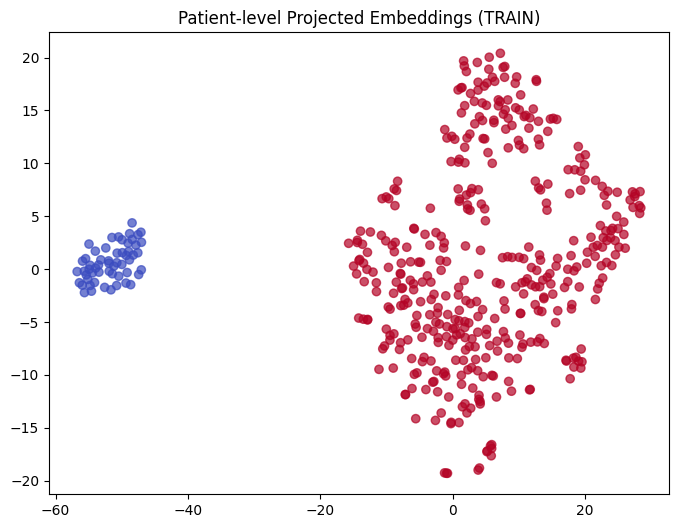

Cosine   intra=0.0053 inter=0.3331 delta=0.3278
Euclid   intra=0.0917 inter=0.8134 delta=0.7217
Silhouette cosine=0.9828 euclidean=0.8855
  Class 0: n=56 cos_intra=0.0046 cos_inter=0.3331 delta=0.3285
  Class 1: n=416 cos_intra=0.0054 cos_inter=0.3331 delta=0.3277

Saved patient-level embeddings to: /media/Data/Yona/WSI CCRCC/runs_supcon_cv_embeddings


In [80]:
BEST_HPARAMS = {
    'epochs': 51, 'batch_size': 128,
    'lr': 0.0005131184270422824, 'temperature': 0.07,
    'noise_std': 0.03065273868172472, 'drop_prob': 0.303790416647357,
    'scale_jitter': 0.1814350939430519, 'lambda_ce': 0.0,
    'weight_decay': 8.104365296022333e-05, 'grad_clip': 5.0,
    'dropout_rate': 0.3, 'exclude_same_patient': True, 'patience': 6, 'seed': 42
}


model_train_only, train_only_ds, train_only_ckpt = train_contrastive_model(
    BEST_HPARAMS, splits=('train',), out_dir=STEP2_TRAINONLY_OUT, tag='contrastive_train_only')


cv_embeddings = extract_and_save_patient_embeddings(
    model_train_only, {'train': ('train',)}, out_dir=CV_EMBED_OUT)

### Nested CV — fold-specific contrastive retrains

In [81]:
N_NESTED_FOLDS = 5

def build_nested_cv_embeddings(hparams, out_dir, n_splits=5, seed=42):
    """For each fold, retrain the contrastive model using ONLY that fold's train-of-train
    patients (excluding the fold's held-out patients), then extract patient-level embeddings
    for both sides from that fold-specific model. Returns the list of fold directories."""
    os.makedirs(out_dir, exist_ok=True)
    all_train_ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train',))
    pid_to_label = {item['patient_id']: item['label'] for item in all_train_ds.data_list}
    pids   = np.array(sorted(pid_to_label.keys()))
    labels = np.array([pid_to_label[p] for p in pids])
    print(f'Nested CV over {len(pids)} train patients (pos={int(labels.sum())}, neg={int((labels==0).sum())})')

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_dirs = []
    for fold, (tr_i, va_i) in enumerate(skf.split(pids, labels)):
        fold_dir = os.path.join(out_dir, f'fold_{fold}')
        os.makedirs(fold_dir, exist_ok=True)
        fold_train_pids = set(pids[tr_i].tolist())
        fold_val_pids   = set(pids[va_i].tolist())
        print(f'\n=== Nested CV fold {fold}/{n_splits-1}: train_pids={len(fold_train_pids)} val_pids={len(fold_val_pids)} ===')
        model_k, _, _ = train_contrastive_model(
            hparams, splits=('train',), out_dir=fold_dir, tag=f'contrastive_fold{fold}',
            patient_ids=fold_train_pids)
        for name, pids_subset in [('train', fold_train_pids), ('val', fold_val_pids)]:
            ds_k = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train',), patient_ids=pids_subset)
            E_slide, y_slide, pid_slide = extract_projected_embeddings(model_k, ds_k)
            E_pat, y_pat, pid_pat = aggregate_patient_max(E_slide, y_slide, pid_slide)
            save_split_embeddings(fold_dir, name, E_pat, y_pat, pid_pat)
        fold_dirs.append(fold_dir)
    return fold_dirs


nested_fold_dirs = build_nested_cv_embeddings(BEST_HPARAMS, NESTED_CV_OUT, n_splits=N_NESTED_FOLDS, seed=42)

Nested CV over 472 train patients (pos=416, neg=56)

=== Nested CV fold 0/4: train_pids=377 val_pids=95 ===
[contrastive_fold0|E01] SupCon 5.7392 CE 1.1376 total 5.7392
[contrastive_fold0|E02] SupCon 5.5184 CE 1.6629 total 5.5184
[contrastive_fold0|E03] SupCon 5.5034 CE 1.8347 total 5.5034
[contrastive_fold0|E04] SupCon 5.4905 CE 1.8393 total 5.4905
[contrastive_fold0|E05] SupCon 5.4750 CE 1.7862 total 5.4750
[contrastive_fold0|E06] SupCon 5.4332 CE 1.7021 total 5.4332
[contrastive_fold0|E07] SupCon 5.4044 CE 1.6137 total 5.4044
[contrastive_fold0|E08] SupCon 5.4054 CE 1.5277 total 5.4054
[contrastive_fold0|E09] SupCon 5.3921 CE 1.4767 total 5.3921
[contrastive_fold0|E10] SupCon 5.3462 CE 1.4001 total 5.3462
[contrastive_fold0|E11] SupCon 5.3022 CE 1.3188 total 5.3022
[contrastive_fold0|E12] SupCon 5.3148 CE 1.2409 total 5.3148
[contrastive_fold0|E13] SupCon 5.2630 CE 1.1796 total 5.2630
[contrastive_fold0|E14] SupCon 5.2377 CE 1.1114 total 5.2377
[contrastive_fold0|E15] SupCon 5.2280 

### Step 2B — Final contrastive model → final patient embeddings

[contrastive_final|E01] SupCon 5.7394 CE 0.5614 total 5.7394
[contrastive_final|E02] SupCon 5.5216 CE 0.4942 total 5.5216
[contrastive_final|E03] SupCon 5.5091 CE 0.4649 total 5.5091
[contrastive_final|E04] SupCon 5.4969 CE 0.4762 total 5.4969
[contrastive_final|E05] SupCon 5.4757 CE 0.4815 total 5.4757
[contrastive_final|E06] SupCon 5.4611 CE 0.4828 total 5.4611
[contrastive_final|E07] SupCon 5.4342 CE 0.4969 total 5.4342
[contrastive_final|E08] SupCon 5.3953 CE 0.5146 total 5.3953
[contrastive_final|E09] SupCon 5.3823 CE 0.5324 total 5.3823
[contrastive_final|E10] SupCon 5.3733 CE 0.5430 total 5.3733
[contrastive_final|E11] SupCon 5.3282 CE 0.5542 total 5.3282
[contrastive_final|E12] SupCon 5.3318 CE 0.5683 total 5.3318
[contrastive_final|E13] SupCon 5.3001 CE 0.5843 total 5.3001
[contrastive_final|E14] SupCon 5.2678 CE 0.5947 total 5.2678
[contrastive_final|E15] SupCon 5.2836 CE 0.6045 total 5.2836
[contrastive_final|E16] SupCon 5.2734 CE 0.6194 total 5.2734
[contrastive_final|E17] 

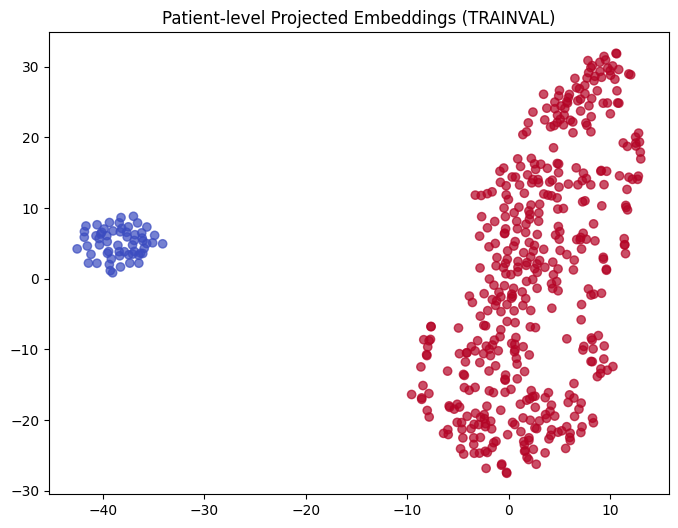

Cosine   intra=0.0142 inter=0.2957 delta=0.2814
Euclid   intra=0.1475 inter=0.7667 delta=0.6192
Silhouette cosine=0.9498 euclidean=0.8133
  Class 0: n=59 cos_intra=0.0020 cos_inter=0.2957 delta=0.2936
  Class 1: n=438 cos_intra=0.0144 cos_inter=0.2957 delta=0.2812

=== Patient-level Projected Embeddings (TEST) === N=120


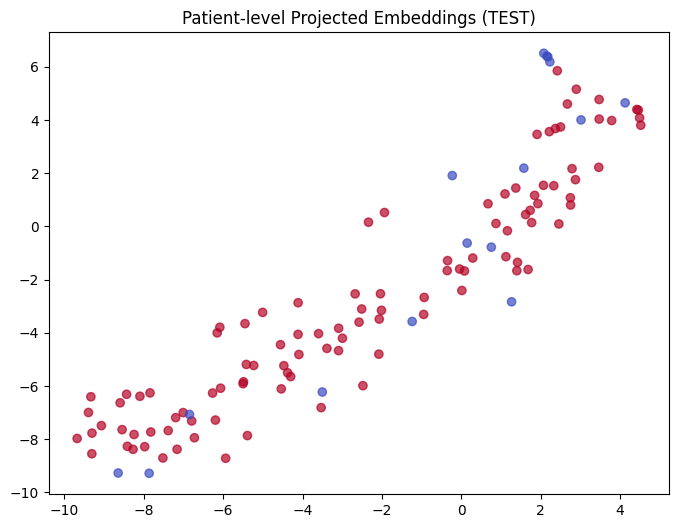

Cosine   intra=0.0299 inter=0.0712 delta=0.0413
Euclid   intra=0.2085 inter=0.3149 delta=0.1064
Silhouette cosine=0.4650 euclidean=0.2782
  Class 0: n=16 cos_intra=0.0927 cos_inter=0.0712 delta=-0.0215
  Class 1: n=104 cos_intra=0.0285 cos_inter=0.0712 delta=0.0428

Saved patient-level embeddings to: /media/Data/Yona/WSI CCRCC/runs_supcon_step3_eval

=== Part 1 (contrastive model) — done ===
Final contrastive checkpoint: /media/Data/Yona/WSI CCRCC/runs_supcon_step2_final/contrastive_final.pth
Patient-level embeddings saved to: /media/Data/Yona/WSI CCRCC/runs_supcon_step3_eval
  trainval: 497 patients, dim=128, pos=438, neg=59
  test: 120 patients, dim=128, pos=104, neg=16


In [82]:
model_final, trainval_slide_ds, final_ckpt = train_contrastive_model(
    BEST_HPARAMS, splits=('train', 'validation'), out_dir=STEP2_OUT, tag='contrastive_final')

final_embeddings = extract_and_save_patient_embeddings(
    model_final, {'trainval': ('train', 'validation'), 'test': ('test',)}, out_dir=STEP3_OUT)

print('\n=== Part 1 (contrastive model) — done ===')
print(f'Final contrastive checkpoint: {final_ckpt}')
print(f'Patient-level embeddings saved to: {STEP3_OUT}')
for name, d in final_embeddings.items():
    print(f'  {name}: {d["E"].shape[0]} patients, dim={d["E"].shape[1]}, '
          f'pos={int(d["y"].sum())}, neg={int((d["y"]==0).sum())}')

# Part 2 — Predictive model (MLP)

## MLP hyperparameter tuning

In [83]:
set_seed(42)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.1, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = float(alpha); self.gamma = float(gamma); self.reduction = reduction

    def forward(self, logits, targets):
        targets  = targets.float()
        bce      = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs    = torch.sigmoid(logits)
        p_t      = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t  = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        loss     = alpha_t * (1.0 - p_t).pow(self.gamma) * bce
        return loss.mean() if self.reduction == 'mean' else (loss.sum() if self.reduction == 'sum' else loss)


class PatientLevelDataset(Dataset):
    def __init__(self, emb_path, label_path, pid_path):
        self.embeddings = np.load(emb_path).astype(np.float32)
        self.labels     = np.load(label_path).astype(np.int64)
        self.pids       = np.load(pid_path)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.embeddings[idx]), torch.tensor(self.labels[idx])


def make_patient_loader(ds, indices=None, batch_size=32, balance=False, seed=42, drop_last=True, shuffle=True):
    """indices=None uses the whole dataset (original behaviour). Pass explicit `indices` to
    restrict the loader to a CV fold."""
    all_idx = np.arange(len(ds)) if indices is None else np.asarray(indices)
    g = torch.Generator(); g.manual_seed(seed)
    if balance:
        rng    = np.random.default_rng(seed)
        labels = ds.labels[all_idx]
        idx0   = all_idx[labels == 0]
        idx1   = all_idx[labels == 1]
        n      = min(len(idx0), len(idx1))
        sel    = np.hstack([rng.choice(idx0, n, replace=True), rng.choice(idx1, n, replace=True)])
        rng.shuffle(sel)
        return DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(sel.tolist()),
                          num_workers=0, generator=g, drop_last=drop_last)
    if shuffle:
        return DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(all_idx.tolist()),
                          num_workers=0, generator=g, drop_last=drop_last)
    subset = torch.utils.data.Subset(ds, all_idx.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=drop_last)


class DeepMLPClassifier(nn.Module):
    """`n_layers` (2-4) selects how many of the [512,256,128,64]-sized blocks (scaled by
    hidden_mult) to keep, closest to the output first — lets the search pick a shallower
    net for a small patient-level dataset instead of always using the full 4-layer depth."""
    def __init__(self, input_dim, dropout=0.5, hidden_mult=1.0, n_layers=4):
        super().__init__()
        def h(base): return max(8, int(base * hidden_mult))
        base_sizes = [512, 256, 128, 64]
        sizes = [h(b) for b in base_sizes[-int(n_layers):]]
        layers, in_dim = [], input_dim
        for s in sizes:
            layers += [nn.Linear(in_dim, s), nn.BatchNorm1d(s), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            in_dim = s
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x).squeeze(1)


@torch.no_grad()
def eval_bacc(model, loader, threshold, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        probs = torch.sigmoid(model(xb.to(device))).cpu().numpy()
        all_preds.extend((probs > threshold).astype(int).tolist())
        all_labels.extend(yb.numpy().astype(int).tolist())
    return balanced_accuracy_score(all_labels, all_preds)


@torch.no_grad()
def find_best_threshold_on_val(model, loader, device, grid=None):
    model.eval()
    probs_all, labels_all = [], []
    for xb, yb in loader:
        probs_all.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        labels_all.append(yb.numpy().astype(int))
    probs_all  = np.concatenate(probs_all)
    labels_all = np.concatenate(labels_all)
    best_t, best_b = 0.5, -1.0
    for t in (grid if grid is not None else np.linspace(0.05, 0.95, 19)):
        b = balanced_accuracy_score(labels_all, (probs_all > t).astype(int))
        if b > best_b: best_b, best_t = b, float(t)
    return best_t, float(best_b)


def train_patient_model_one_run_optuna(train_loader, valid_loader, input_dim,
                                        lr, wd, n_epochs, noise_std, dropout,
                                        focal_alpha, focal_gamma,
                                        threshold_mode, threshold_value,
                                        hidden_mult, seed, n_layers=4, trial=None, return_model=False):
    set_seed(seed)
    model     = DeepMLPClassifier(input_dim=input_dim, dropout=dropout, hidden_mult=hidden_mult, n_layers=n_layers).to(device)
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    g_noise   = torch.Generator(device=device); g_noise.manual_seed(seed)
    best_bacc, best_thr, best_state, best_epoch = -1.0, 0.5, None, 0
    for ep in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            if xb.size(0) < 2: continue
            xb, yb = xb.to(device), yb.to(device)
            if noise_std and (yb == 0).any():
                mask = (yb == 0)
                xb = xb.clone()
                xb[mask] = xb[mask] + torch.randn(xb[mask].shape, device=device, generator=g_noise) * noise_std
            loss = criterion(model(xb), yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        thr, bacc = (find_best_threshold_on_val(model, valid_loader, device=device)
                     if threshold_mode == 'auto'
                     else (float(threshold_value), eval_bacc(model, valid_loader, float(threshold_value), device)))
        if trial is not None:
            trial.report(bacc, step=ep)
            if trial.should_prune(): raise optuna.TrialPruned()
        if bacc > best_bacc:
            best_bacc, best_thr, best_epoch = float(bacc), float(thr), ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None: model.load_state_dict(best_state)
    if return_model:
        return best_bacc, best_thr, model, best_epoch
    return best_bacc, best_thr


def load_nested_cv_datasets(fold_dirs):
    """Loads the precomputed (fold-train, fold-val) PatientLevelDataset pairs produced by
    build_nested_cv_embeddings — each pair comes from a contrastive model that never saw that
    fold's val patients, so CV over these pairs carries no representation-level leakage."""
    datasets = []
    for fold_dir in fold_dirs:
        train_ds_k = PatientLevelDataset(f'{fold_dir}/train_projected.npy', f'{fold_dir}/train_labels.npy', f'{fold_dir}/train_patient_ids.npy')
        val_ds_k   = PatientLevelDataset(f'{fold_dir}/val_projected.npy',   f'{fold_dir}/val_labels.npy',   f'{fold_dir}/val_patient_ids.npy')
        datasets.append((train_ds_k, val_ds_k))
    return datasets


def cv_bacc_for_params(nested_datasets, input_dim, params, seed=42, trial=None):
    """Evaluate `params` across the precomputed nested-CV folds. Each fold's TRAIN/VAL patient
    embeddings come from a contrastive model that never saw that fold's VAL patients — a genuine
    hold-out, unlike splitting a single train-only embedding array (which we verified gives
    BACC=1.0 on every config, since that shared model already used every patient's label)."""
    baccs, thrs = [], []
    for fold, (train_ds_k, val_ds_k) in enumerate(nested_datasets):
        tr_ld = make_patient_loader(train_ds_k, batch_size=params['batch_size'],
                                    balance=params['balance_train'], seed=seed, drop_last=True)
        va_ld = make_patient_loader(val_ds_k, batch_size=params['batch_size'],
                                    balance=False, seed=seed, drop_last=False, shuffle=False)
        bacc, thr = train_patient_model_one_run_optuna(
            tr_ld, va_ld, input_dim, lr=params['lr'], wd=params['wd'], n_epochs=params['epochs'],
            noise_std=params['noise_std'], dropout=params['dropout'],
            focal_alpha=params['focal_alpha'], focal_gamma=params['focal_gamma'],
            threshold_mode=params['threshold_mode'], threshold_value=params['threshold_value'],
            hidden_mult=params['hidden_mult'], n_layers=params.get('n_layers', 4), seed=seed, trial=None,
        )
        baccs.append(bacc); thrs.append(thr)
        if trial is not None:
            trial.report(float(np.mean(baccs)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return float(np.mean(baccs)), float(np.std(baccs)), float(np.mean(thrs))


def cv_best_epochs_for_params(nested_datasets, input_dim, params, seed=42):
    """Re-runs the (cheap) nested-CV folds for one fixed hyperparameter config, this time
    capturing the epoch at which each fold's best checkpoint occurred. Used to derive a
    principled epoch budget for the final TRAIN+VAL fit — see the final-model cell for why
    we can't just early-stop on a fresh split of the final (leaky) TRAIN+VAL embeddings."""
    epochs_per_fold = []
    for train_ds_k, val_ds_k in nested_datasets:
        tr_ld = make_patient_loader(train_ds_k, batch_size=params['batch_size'],
                                    balance=params['balance_train'], seed=seed, drop_last=True)
        va_ld = make_patient_loader(val_ds_k, batch_size=params['batch_size'],
                                    balance=False, seed=seed, drop_last=False, shuffle=False)
        _, _, _, best_epoch = train_patient_model_one_run_optuna(
            tr_ld, va_ld, input_dim, lr=params['lr'], wd=params['wd'], n_epochs=params['epochs'],
            noise_std=params['noise_std'], dropout=params['dropout'],
            focal_alpha=params['focal_alpha'], focal_gamma=params['focal_gamma'],
            threshold_mode=params['threshold_mode'], threshold_value=params['threshold_value'],
            hidden_mult=params['hidden_mult'], n_layers=params.get('n_layers', 4), seed=seed,
            trial=None, return_model=True)
        epochs_per_fold.append(best_epoch)
    return epochs_per_fold

In [84]:
nested_fold_dirs   = [f'{NESTED_CV_OUT}/fold_{i}' for i in range(N_NESTED_FOLDS)]
nested_cv_datasets = load_nested_cv_datasets(nested_fold_dirs)
input_dim = nested_cv_datasets[0][0].embeddings.shape[1]
for k, (tr_k, va_k) in enumerate(nested_cv_datasets):
    print(f'Fold {k}: train patients={len(tr_k)} (pos={int(tr_k.labels.sum())}), '
          f'val patients={len(va_k)} (pos={int(va_k.labels.sum())})')

STABILITY_WEIGHT  = 0.5   # objective = mean_bacc - STABILITY_WEIGHT * std_bacc


def objective(trial):
    seed           = 42
    lr             = trial.suggest_float('lr', 1e-5, 5e-2, log=True)
    wd             = trial.suggest_float('wd', 1e-7, 1e-3, log=True)
    dropout        = trial.suggest_float('dropout', 0.0, 0.7)
    n_epochs       = trial.suggest_int('epochs', 20, 80)
    batch_size     = trial.suggest_categorical('batch_size', [8, 16, 32, 64, 128])
    noise_std      = trial.suggest_float('noise_std', 0.0, 0.05)
    focal_alpha    = trial.suggest_float('focal_alpha', 0.01, 0.5)
    focal_gamma    = trial.suggest_float('focal_gamma', 0.5, 5.0)
    hidden_mult    = trial.suggest_float('hidden_mult', 0.5, 1.5)
    n_layers       = trial.suggest_int('n_layers', 2, 4)
    threshold_mode = trial.suggest_categorical('threshold_mode', ['auto', 'fixed'])
    threshold_val  = 0.5 if threshold_mode == 'auto' else trial.suggest_float('threshold', 0.05, 0.95)
    balance_train  = trial.suggest_categorical('balance_train', [True, False])
    params = dict(lr=lr, wd=wd, dropout=dropout, epochs=n_epochs, batch_size=batch_size,
                  noise_std=noise_std, focal_alpha=focal_alpha, focal_gamma=focal_gamma,
                  hidden_mult=hidden_mult, n_layers=n_layers,
                  threshold_mode=threshold_mode, threshold_value=threshold_val,
                  balance_train=balance_train)
    mean_bacc, std_bacc, mean_thr = cv_bacc_for_params(nested_cv_datasets, input_dim, params, seed=seed, trial=trial)
    trial.set_user_attr('mean_bacc', mean_bacc)
    trial.set_user_attr('bacc_std', std_bacc)

    trial.set_user_attr('best_threshold', mean_thr)
    return mean_bacc - STABILITY_WEIGHT * std_bacc


sampler = optuna.samplers.TPESampler(seed=42, multivariate=True, group=True)
study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=MedianPruner(n_startup_trials=15, n_warmup_steps=2, interval_steps=1)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print('Best objective (mean_bacc - %.2f*std_bacc):' % STABILITY_WEIGHT, study.best_value)
print('  -> raw mean BACC:', study.best_trial.user_attrs['mean_bacc'],
      '+/- std', study.best_trial.user_attrs['bacc_std'])
print('Best Params:  ', study.best_params)
print('Best Threshold:', study.best_trial.user_attrs['best_threshold'])

leaderboard = sorted(
    (t for t in study.trials if t.value is not None),
    key=lambda t: t.user_attrs.get('mean_bacc', -1), reverse=True
)[:10]
print('\n=== Top 10 trials by raw mean BACC ===')
for t in leaderboard:
    print(f"trial {t.number:3d} | mean_bacc={t.user_attrs['mean_bacc']:.4f} "
          f"+/- {t.user_attrs['bacc_std']:.4f} | obj={t.value:.4f} | params={t.params}")

 
best_params_for_cv = dict(study.best_params)
best_params_for_cv['threshold_value'] = best_params_for_cv.pop('threshold', 0.5)

epochs_per_fold  = cv_best_epochs_for_params(nested_cv_datasets, input_dim, best_params_for_cv, seed=42)
FINAL_NUM_EPOCHS = int(round(float(np.median(epochs_per_fold))))
FINAL_THRESHOLD  = float(study.best_trial.user_attrs['best_threshold'])

print(f'\nPer-fold best epoch: {epochs_per_fold} -> fixed budget for final fit: {FINAL_NUM_EPOCHS} epochs')
print(f'Fixed decision threshold for final fit (nested-CV mean): {FINAL_THRESHOLD:.4f}')


/home/yona/miniconda3/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-08-18 18:34:21,524] A new study created in memory with name: no-name-51aeaa72-a0b8-4a9c-9e99-0800ebe6777b


Fold 0: train patients=377 (pos=332), val patients=95 (pos=84)
Fold 1: train patients=377 (pos=333), val patients=95 (pos=83)
Fold 2: train patients=378 (pos=333), val patients=94 (pos=83)
Fold 3: train patients=378 (pos=333), val patients=94 (pos=83)
Fold 4: train patients=378 (pos=333), val patients=94 (pos=83)


  0%|          | 0/200 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.5:   0%|          | 1/200 [00:02<09:15,  2.79s/it]

[I 2026-08-18 18:34:24,314] Trial 0 finished with value: 0.5 and parameters: {'lr': 0.00024289169469748895, 'wd': 0.0006351221010640698, 'dropout': 0.5123957592679835, 'epochs': 56, 'batch_size': 64, 'noise_std': 0.03540362888980227, 'focal_alpha': 0.020086402204943198, 'focal_gamma': 4.864594334728975, 'hidden_mult': 1.3324426408004217, 'n_layers': 2, 'threshold_mode': 'fixed', 'threshold': 0.3238180186635839, 'balance_train': True}. Best is trial 0 with value: 0.5.


...

[I 2026-08-18 20:09:10,249] Trial 197 finished with value: 0.7556069729379521 and parameters: {'lr': 0.00019440636869774814, 'wd': 2.810490656247626e-07, 'dropout': 0.11166552998473278, 'epochs': 60, 'batch_size': 16, 'noise_std': 0.01151474089860996, 'focal_alpha': 0.47490643831858126, 'focal_gamma': 3.793680908901014, 'hidden_mult': 1.0299854999756362, 'n_layers': 3, 'threshold_mode': 'auto', 'balance_train': True}. Best is trial 45 with value: 0.7663624097076207.


Best trial: 45. Best value: 0.766362: 100%|█████████▉| 199/200 [1:35:07<00:25, 25.93s/it]

[I 2026-08-18 20:09:28,868] Trial 198 pruned. 


Best trial: 45. Best value: 0.766362: 100%|██████████| 200/200 [1:35:29<00:00, 28.65s/it]


[I 2026-08-18 20:09:50,764] Trial 199 pruned. 
Best objective (mean_bacc - 0.50*std_bacc): 0.7663624097076207
  -> raw mean BACC: 0.7712186407969541 +/- std 0.009712462178666907
Best Params:   {'lr': 0.001131544494338524, 'wd': 5.666783595422346e-06, 'dropout': 0.09698773005533687, 'epochs': 61, 'batch_size': 8, 'noise_std': 0.010057278027358634, 'focal_alpha': 0.42653576436395924, 'focal_gamma': 1.480642410346115, 'hidden_mult': 1.138316836102648, 'n_layers': 3, 'threshold_mode': 'auto', 'balance_train': True}
Best Threshold: 0.8699999999999999

=== Top 10 trials by raw mean BACC ===
trial 190 | mean_bacc=0.7772 +/- 0.0481 | obj=0.7531 | params={'lr': 4.606623055626722e-05, 'wd': 4.3490306059137426e-07, 'dropout': 0.338440495989131, 'epochs': 60, 'batch_size': 16, 'noise_std': 0.0016657907550628771, 'focal_alpha': 0.48995846893615436, 'focal_gamma': 2.32856580345378, 'hidden_mult': 0.6917560353015283, 'n_layers': 4, 'threshold_mode': 'auto', 'balance_train': True}
trial 145 | mean_bac

## Final MLP :  TRAIN+VAL embeddings → test evaluation

In [136]:
CFG = {
    'lr':             0.0005804100646865201,
    'weight_decay':   0.00012399614112130233,
    'dropout':        0.30921021354885325,
    'hidden_mult':    0.9787041890827725,
    'n_layers':       4,
    'batch_size':     32,
    'noise_std':      0.04153716873775404,
    'focal_alpha':    0.25,
    'focal_gamma':    1.4806,
    'balance_train':  False,

    'num_epochs':     20,
    'threshold':      0.87,
    'threshold_grid': np.round(np.arange(0.05, 0.96, 0.01), 2),
    'seed':           42,
}

Patients — train:497 test:120 diag_val(orig split):25 | input_dim=128
Fixed epoch budget: 20 | fixed threshold: 0.8700 (both from nested-CV, no val/test monitoring during this fit)
Epoch 1/20 | Train Loss=0.0521 Acc=0.8813 || Val (orig split) Loss=0.0682 BACC=0.5000
Epoch 2/20 | Train Loss=0.0268 Acc=0.8813 || Val (orig split) Loss=0.0672 BACC=1.0000
Epoch 3/20 | Train Loss=0.0204 Acc=0.8813 || Val (orig split) Loss=0.0673 BACC=1.0000
Epoch 4/20 | Train Loss=0.0216 Acc=0.9940 || Val (orig split) Loss=0.0302 BACC=1.0000
Epoch 5/20 | Train Loss=0.0128 Acc=1.0000 || Val (orig split) Loss=0.0131 BACC=1.0000
Epoch 6/20 | Train Loss=0.0136 Acc=1.0000 || Val (orig split) Loss=0.0090 BACC=1.0000
Epoch 7/20 | Train Loss=0.0096 Acc=1.0000 || Val (orig split) Loss=0.0075 BACC=1.0000
Epoch 8/20 | Train Loss=0.0071 Acc=1.0000 || Val (orig split) Loss=0.0056 BACC=1.0000
Epoch 9/20 | Train Loss=0.0063 Acc=1.0000 || Val (orig split) Loss=0.0051 BACC=1.0000
Epoch 10/20 | Train Loss=0.0057 Acc=1.0000 ||

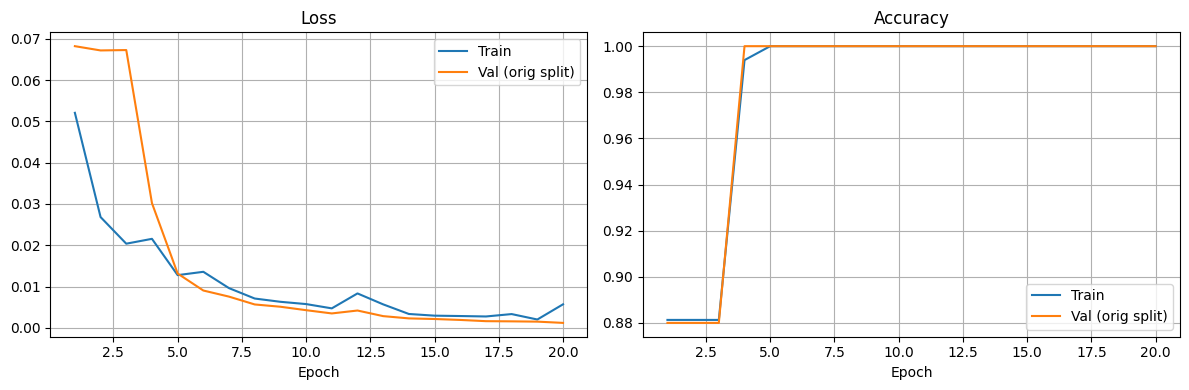


TEST RESULTS  (threshold=0.87)
ACC    : 0.8667
BACC   : 0.7115
AUC    : 0.7001
Recall  class0=0.5000  class1=0.9231
Precision class0=0.5000  class1=0.9231
Macro-F1: 0.7115
Confusion (tn,fp,fn,tp): 8,8,8,96

                  precision    recall  f1-score   support

Non-survivor (0)       0.50      0.50      0.50        16
    Survivor (1)       0.92      0.92      0.92       104

        accuracy                           0.87       120
       macro avg       0.71      0.71      0.71       120
    weighted avg       0.87      0.87      0.87       120



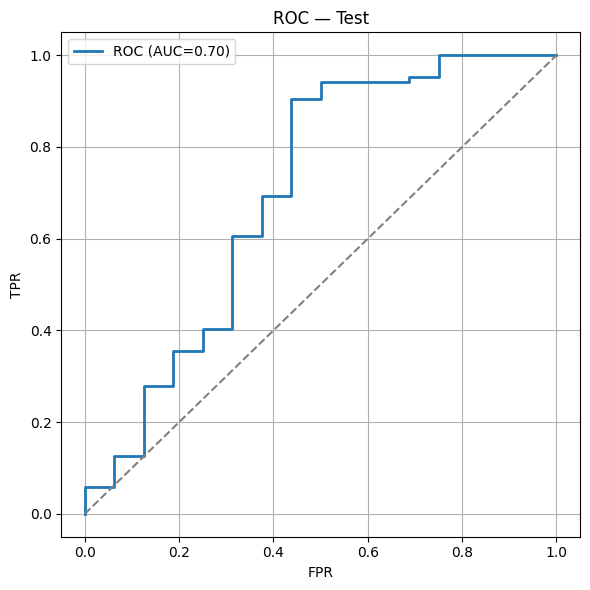

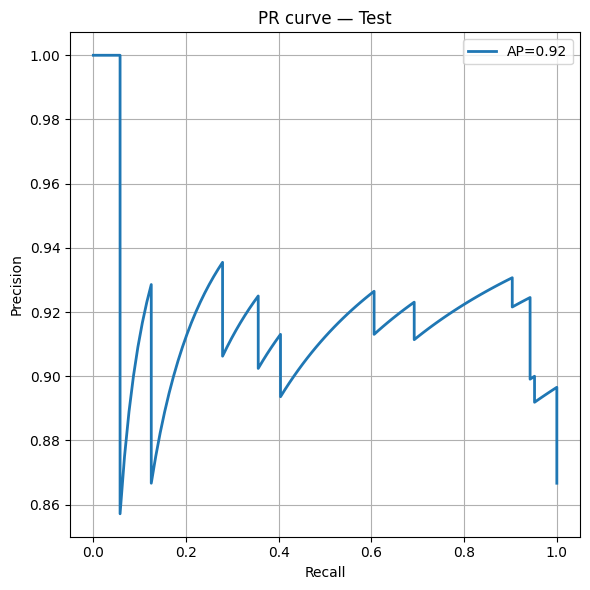

In [137]:

set_seed(CFG['seed'])

def load_patient_ds(prefix, root):
    return PatientLevelDataset(f'{root}/{prefix}_projected.npy',
                               f'{root}/{prefix}_labels.npy',
                               f'{root}/{prefix}_patient_ids.npy')


train_ds  = load_patient_ds('trainval', STEP3_OUT)
test_ds   = load_patient_ds('test', STEP3_OUT)
input_dim = train_ds.embeddings.shape[1]

# Original 'validation'-split patients (still inside `trainval`, part of training).
# Diagnostic only: NOT excluded from training, NOT used for epoch/threshold selection.
split_df      = pd.read_csv(CSV_PATH)[['case_id', 'Split']]
orig_val_pids = set(split_df.loc[split_df['Split'] == 'validation', 'case_id'])
diag_val_idx  = np.where(np.isin(train_ds.pids, list(orig_val_pids)))[0]
diag_val_ld   = (make_patient_loader(train_ds, indices=diag_val_idx, batch_size=CFG['batch_size'],
                                     balance=False, seed=CFG['seed'], drop_last=False, shuffle=False)
                 if len(diag_val_idx) > 0 else None)

tr_ld = make_patient_loader(train_ds, batch_size=CFG['batch_size'], balance=CFG['balance_train'],
                            seed=CFG['seed'], drop_last=True)
te_ld = make_patient_loader(test_ds, batch_size=CFG['batch_size'], balance=False,
                            seed=CFG['seed'], drop_last=False, shuffle=False)

# Non-augmented pass over all of train, used only to report train accuracy each epoch.
train_eval_ld = make_patient_loader(train_ds, batch_size=CFG['batch_size'], balance=False,
                                    seed=CFG['seed'], drop_last=False, shuffle=False)

print(f'Patients — train:{len(train_ds)} test:{len(test_ds)} '
      f'diag_val(orig split):{len(diag_val_idx)} | input_dim={input_dim}')
print(f"Fixed epoch budget: {CFG['num_epochs']} | fixed threshold: {CFG['threshold']:.4f} "
      f'(both from nested-CV, no val/test monitoring during this fit)')


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Return (probs_class1, labels, mean_loss). mean_loss is None without criterion."""
    model.eval()
    probs, labels, tot_loss, n = [], [], 0.0, 0
    for Xb, yb in loader:
        logits = model(Xb.to(device))
        if criterion is not None:
            tot_loss += criterion(logits, yb.to(device)).item() * Xb.size(0)
            n        += Xb.size(0)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(yb.numpy())
    mean_loss = tot_loss / max(n, 1) if criterion is not None else None
    return np.concatenate(probs).astype(float), np.concatenate(labels).astype(int), mean_loss


def best_threshold(probs, labels, grid):
    """Threshold maximising balanced accuracy on the given probabilities."""
    baccs = [balanced_accuracy_score(labels, (probs > t).astype(int)) for t in grid]
    i = int(np.argmax(baccs))
    return float(grid[i]), float(baccs[i])


def noisy_negatives(Xb, yb, std, generator):
    """Gaussian augmentation applied to class-0 samples only."""
    mask = (yb == 0)
    if not std or not mask.any():
        return Xb
    Xb = Xb.clone()
    Xb[mask] = Xb[mask] + torch.randn(Xb[mask].shape, device=device, generator=generator) * std
    return Xb


def run_epoch(model, loader, criterion, optimizer, generator):
    model.train()
    run_loss, total = 0.0, 0
    for Xb, yb in loader:
        if Xb.size(0) < 2:
            continue
        Xb, yb = Xb.to(device), yb.to(device)
        Xb = noisy_negatives(Xb, yb, CFG['noise_std'], generator)
        loss = criterion(model(Xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * Xb.size(0)
        total    += Xb.size(0)
    return run_loss / max(total, 1)


def train_model(train_loader, input_dim, cfg, diag_loader=None, diag_name='Val', train_eval_loader=None):
    """Train for a fixed `cfg['num_epochs']` epochs — no early stopping. The epoch budget and
    decision threshold are both fixed beforehand from the leakage-free nested-CV search, so this
    function never looks at val or test during training."""
    set_seed(cfg['seed'])
    model     = DeepMLPClassifier(input_dim=input_dim, dropout=cfg['dropout'],
                                  hidden_mult=cfg['hidden_mult'],
                                  n_layers=cfg['n_layers']).to(device)
    criterion = FocalLoss(alpha=cfg['focal_alpha'], gamma=cfg['focal_gamma'])
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    generator = torch.Generator(device=device); generator.manual_seed(cfg['seed'])

    history = {'train_loss': [], 'train_acc': [], 'diag_loss': [], 'diag_bacc': [], 'diag_acc': []}

    for epoch in range(1, cfg['num_epochs'] + 1):
        tr_loss = run_epoch(model, train_loader, criterion, optimizer, generator)
        history['train_loss'].append(tr_loss)

        tr_probs, tr_ys, _ = evaluate(model, train_eval_loader)
        history['train_acc'].append(accuracy_score(tr_ys, (tr_probs > 0.5).astype(int)))

        diag_str = ''
        if diag_loader is not None:
            diag_probs, diag_ys, diag_loss = evaluate(model, diag_loader, criterion)
            _, diag_bacc                   = best_threshold(diag_probs, diag_ys, cfg['threshold_grid'])
            history['diag_loss'].append(diag_loss)
            history['diag_bacc'].append(diag_bacc)
            history['diag_acc'].append(accuracy_score(diag_ys, (diag_probs > 0.5).astype(int)))
            diag_str = f' || {diag_name} Loss={diag_loss:.4f} BACC={diag_bacc:.4f}'

        print(f'Epoch {epoch}/{cfg["num_epochs"]} | '
              f'Train Loss={tr_loss:.4f} Acc={history["train_acc"][-1]:.4f}'
              + diag_str)

    return model, history


model, history = train_model(tr_ld, input_dim, CFG, diag_loader=diag_val_ld,
                             diag_name='Val (orig split)', train_eval_loader=train_eval_ld)
final_threshold = CFG['threshold']
print(f"\nTraining done: {CFG['num_epochs']} epochs, fixed threshold={final_threshold:.4f} "
      f'(both from nested-CV — no val/test monitoring during this fit).')

epochs = range(1, CFG['num_epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], label='Train')
if diag_val_ld is not None:
    axes[0].plot(epochs, history['diag_loss'], label='Val (orig split)')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend()
axes[1].plot(epochs, history['train_acc'], label='Train')
if diag_val_ld is not None:
    axes[1].plot(epochs, history['diag_acc'], label='Val (orig split)')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()


p1, y_true, _ = evaluate(model, te_ld)
thr    = final_threshold
y_pred = (p1 > thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
recall_0    = tn / (tn + fp + 1e-12)
recall_1    = tp / (tp + fn + 1e-12)
precision_0 = tn / (tn + fn + 1e-12)
precision_1 = tp / (tp + fp + 1e-12)
bacc        = 0.5 * (recall_0 + recall_1)
f1_0        = 2 * precision_0 * recall_0 / (precision_0 + recall_0 + 1e-12)
f1_1        = 2 * precision_1 * recall_1 / (precision_1 + recall_1 + 1e-12)
auc_score   = roc_auc_score(y_true, p1)

print(f'\nTEST RESULTS  (threshold={thr})')
print(f'ACC    : {accuracy_score(y_true, y_pred):.4f}')
print(f'BACC   : {bacc:.4f}')
print(f'AUC    : {auc_score:.4f}')
print(f'Recall  class0={recall_0:.4f}  class1={recall_1:.4f}')
print(f'Precision class0={precision_0:.4f}  class1={precision_1:.4f}')
print(f'Macro-F1: {0.5 * (f1_0 + f1_1):.4f}')
print(f'Confusion (tn,fp,fn,tp): {tn},{fp},{fn},{tp}')
print()
print(classification_report(y_true, y_pred, target_names=['Non-survivor (0)', 'Survivor (1)']))

fpr, tpr, _ = roc_curve(y_true, p1)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Test'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_true, p1)
ap = average_precision_score(y_true, p1)
plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, lw=2, label=f'AP={ap:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve — Test'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()